In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('hotel_bookings_updated_2024.csv')

In [4]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,city
0,Resort Hotel - Chandigarh,0,342,2024,July,30,27,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2024-07-27 22:16:40.916332324,Chandigarh
1,Resort Hotel - Mumbai,0,737,2024,April,17,28,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2024-04-28 21:56:21.507509066,Mumbai
2,Resort Hotel - Delhi,0,7,2024,September,37,10,0,1,1,...,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2024-09-10 03:46:25.734029096,Delhi
3,Resort Hotel - Kolkata,0,13,2024,August,33,14,0,1,1,...,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2024-08-14 18:07:10.049669568,Kolkata
4,Resort Hotel - Lucknow,0,14,2024,September,37,14,0,2,2,...,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2024-09-14 14:27:32.473846000,Lucknow


In [5]:
df.shape

(119390, 33)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [7]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date', 'city'],
      dtype='object')

In [8]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])

In [10]:
# df.info()

In [11]:
df.describe(include='object')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status,city
count,119390,119390,119390,118902,119390,119390,119390,119390,119390,119390,119390,119390
unique,30,12,5,177,8,5,10,12,3,4,3,15
top,City Hotel - Ahmedabad,October,BB,PRT,Online TA,TA/TO,A,A,No Deposit,Transient,Check-Out,Bhopal
freq,5405,10349,92310,48590,56477,97870,85994,74053,104641,89613,75166,8104


In [12]:
for col in df.describe(include='object').columns:
    print(col)
    print(df[col].unique())
    print('-'*50)

hotel
['Resort Hotel - Chandigarh' 'Resort Hotel - Mumbai'
 'Resort Hotel - Delhi' 'Resort Hotel - Kolkata' 'Resort Hotel - Lucknow'
 'Resort Hotel - Indore' 'Resort Hotel - Ahmedabad' 'Resort Hotel - Pune'
 'Resort Hotel - Chennai' 'Resort Hotel - Bhopal'
 'Resort Hotel - Hyderabad' 'Resort Hotel - Kochi'
 'Resort Hotel - Bangalore' 'Resort Hotel - Jaipur' 'Resort Hotel - Goa'
 'City Hotel - Ahmedabad' 'City Hotel - Indore' 'City Hotel - Jaipur'
 'City Hotel - Pune' 'City Hotel - Hyderabad' 'City Hotel - Bhopal'
 'City Hotel - Kolkata' 'City Hotel - Mumbai' 'City Hotel - Bangalore'
 'City Hotel - Lucknow' 'City Hotel - Chennai' 'City Hotel - Chandigarh'
 'City Hotel - Delhi' 'City Hotel - Kochi' 'City Hotel - Goa']
--------------------------------------------------
arrival_date_month
['July' 'April' 'September' 'August' 'October' 'January' 'December'
 'March' 'June' 'November' 'February' 'May']
--------------------------------------------------
meal
['BB' 'FB' 'HB' 'SC' 'Undefined']
-

In [13]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [14]:
df.drop(['agent','company'], axis = 1, inplace = True)
df.dropna(inplace = True)

In [15]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests   

In [16]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,118898.000000,118898.000000,118898.0,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898.000000,118898
mean,0.371352,104.311435,2024.0,26.377626,15.724083,0.928897,2.502145,1.858391,0.104207,0.007948,0.032011,0.087142,0.131634,0.221181,2.330754,102.003243,0.061885,0.571683,2024-07-01 01:55:09.676197888
min,0.000000,0.000000,2024.0,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000,2024-01-01 00:00:00
25%,0.000000,18.000000,2024.0,13.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,70.000000,0.000000,0.000000,2024-03-31 20:36:29.447939072
50%,0.000000,69.000000,2024.0,26.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,95.000000,0.000000,0.000000,2024-07-01 03:24:55.042256896
75%,1.000000,161.000000,2024.0,39.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000,2024-09-30 09:39:13.513305344
max,1.000000,737.000000,2024.0,52.000000,31.000000,16.000000,41.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000,2024-12-31 00:00:00
std,0.483168,106.903309,0.0,15.023068,8.804413,0.996216,1.900168,0.578576,0.399172,0.097380,0.176029,0.845869,1.484672,0.652785,17.630452,50.485862,0.244172,0.792678,NaN


In [26]:
df = df[df['adr']<5000]

In [28]:
# df.describe()

# Data Analysis & Visualization

is_canceled
0    0.628653
1    0.371347
Name: proportion, dtype: float64


<BarContainer object of 2 artists>

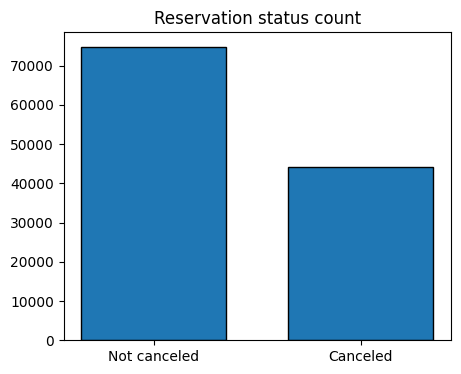

In [42]:
# Total_Cancelation = (df['is_canceled'].value_counts() / len(df) ) * 100
Total_Cancelation = df['is_canceled'].value_counts(normalize = True)
print(Total_Cancelation)

plt.figure(figsize = (5, 4))
plt.title('Reservation status count')
plt.bar(['Not canceled', 'Canceled'], df['is_canceled'].value_counts(), edgecolor = 'black', width=0.7)

In [52]:
df['hotel_type'] = df['hotel'].str.split(' -').str[0]

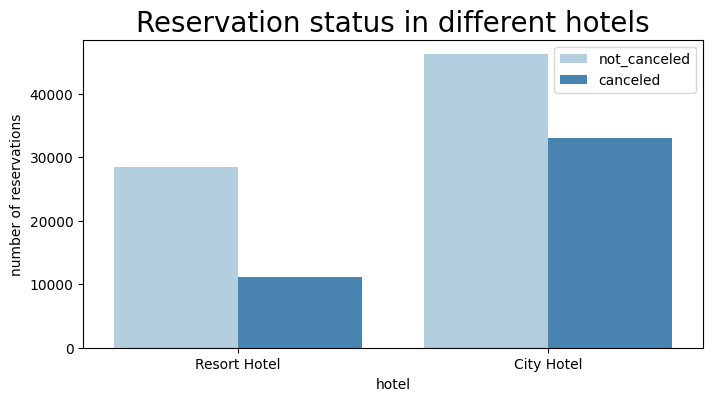

In [53]:
plt.figure(figsize=(8,4))
ax1 = sns.countplot(x = 'hotel_type', hue = 'is_canceled', data = df, palette = 'Blues')
legend_labels,_ = ax1.get_legend_handles_labels()
ax1.legend(bbox_to_anchor=(1,1))
plt.title('Reservation status in different hotels', size=20)
plt.xlabel('hotel')
plt.ylabel('number of reservations')
plt.legend(['not_canceled', 'canceled'])
plt.show()

# plt.figure(figsize=(8,4))
# ax1 = sns.countplot(
#     x='hotel_type', 
#     hue='is_canceled', 
#     data=df, 
#     palette='Blues')
# # Fix legend labels properly
# handles, labels = ax1. get_legend_handles_labels()
# ax1.legend(handles, ['not_canceled', 'canceled'], bbox_to_anchor=(1,1))
# plt.title('Reservation status in different hotels', size=20)
# plt.xlabel('hotel')
# plt.ylabel('number of reservations')
# plt.show()

In [58]:
# Check percentages of cancelation in both Resort hotel and City hotel
# For resort hotel
resort_hotel = df[df['hotel_type'] == 'Resort Hotel']
resort_hotel['is_canceled'].value_counts(normalize=True)

is_canceled
0    0.72025
1    0.27975
Name: proportion, dtype: float64

In [59]:
# For city hotel
city_hotel = df[df['hotel_type'] == 'City Hotel']
city_hotel['is_canceled'].value_counts(normalize=True)

is_canceled
0    0.582918
1    0.417082
Name: proportion, dtype: float64

In [61]:
resort_hotel = resort_hotel.groupby('reservation_status_date')[['adr']].mean()
city_hotel = city_hotel.groupby('reservation_status_date')[['adr']].mean()

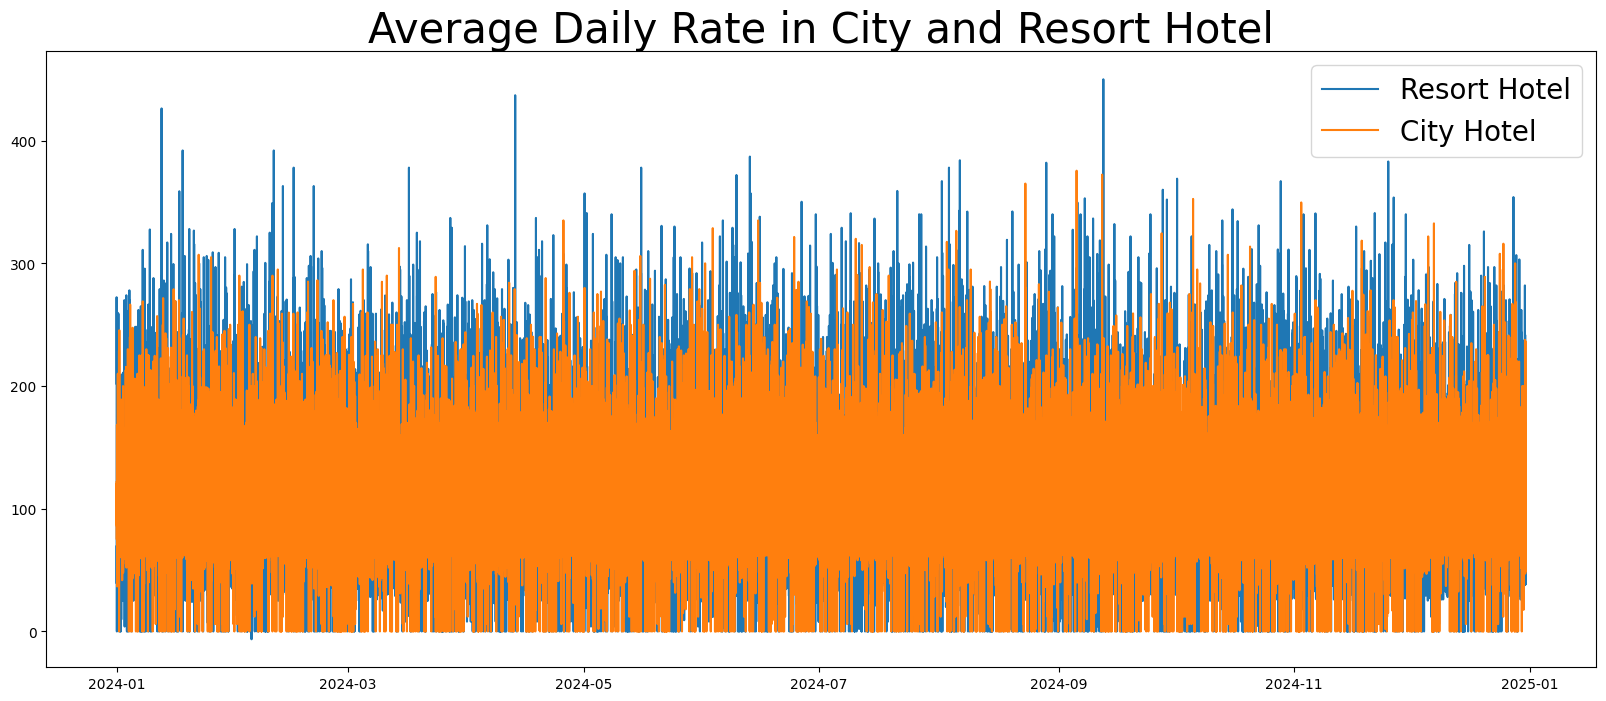

In [65]:
plt.figure(figsize = (20,8))
plt.title('Average Daily Rate in City and Resort Hotel', fontsize=30)
plt.plot(resort_hotel.index, resort_hotel['adr'], label = 'Resort Hotel')
plt.plot(city_hotel.index, city_hotel['adr'], label = 'City Hotel')
plt.legend(fontsize=20)
plt.show()

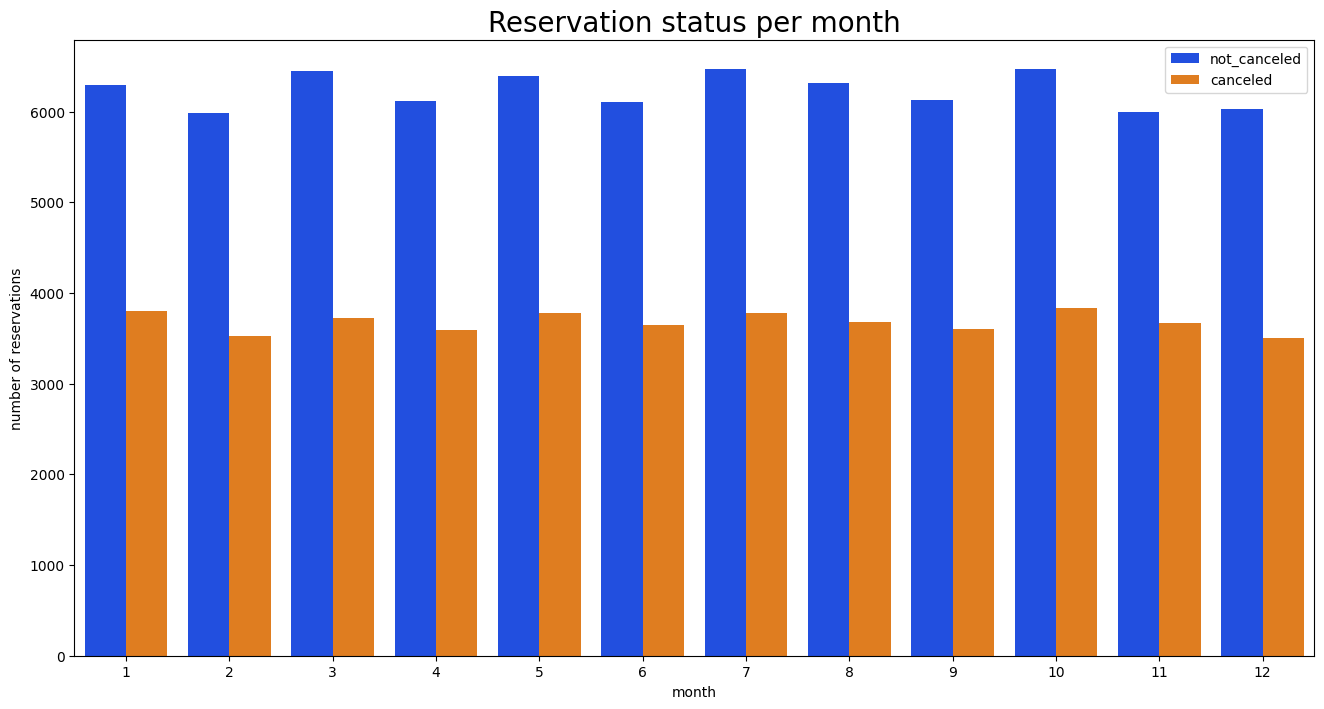

In [69]:
df['month']= df['reservation_status_date'].dt.month
plt.figure(figsize = (16,8))
ax1 = sns.countplot(x = 'month', hue = 'is_canceled', data = df, palette = 'bright')
legend_labels,_ = ax1.get_legend_handles_labels()
ax1.legend(bbox_to_anchor=(1,1))
plt.title('Reservation status per month', size=20)
plt.xlabel('month')
plt.ylabel('number of reservations')
plt.legend(['not_canceled', 'canceled'])
plt.show()

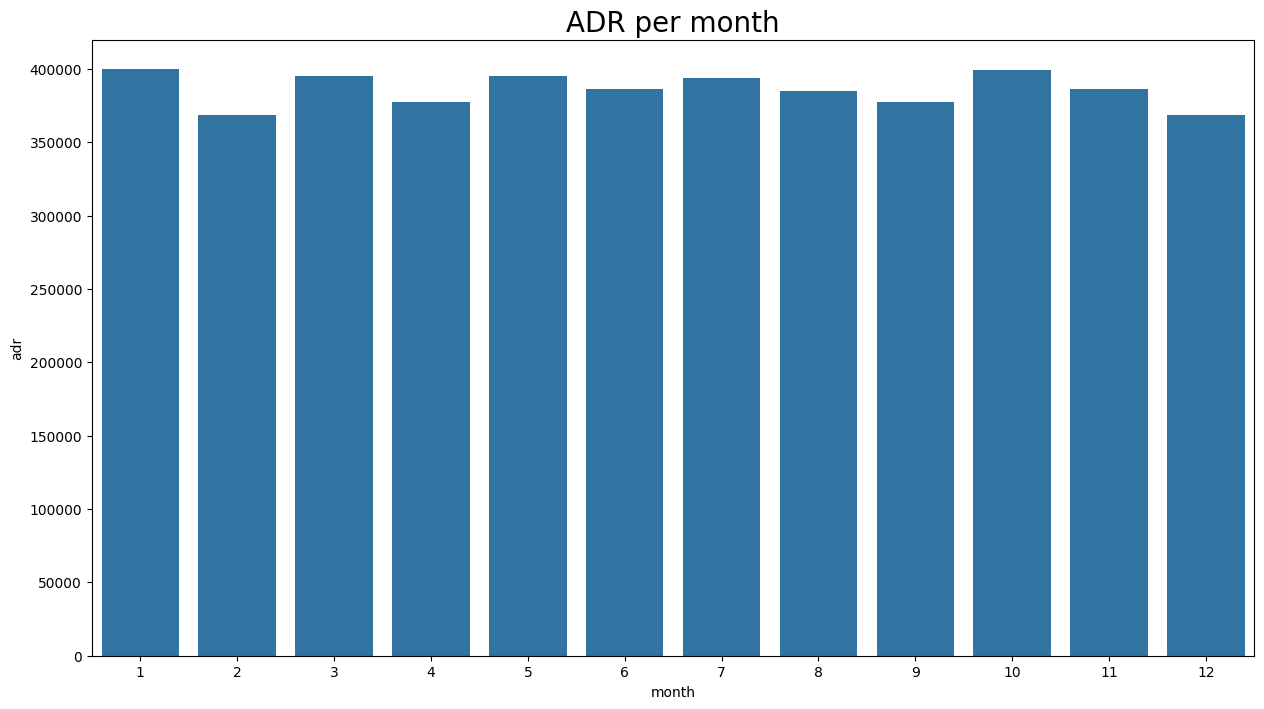

In [114]:
plt.figure(figsize = (15,8))
plt.title("ADR per month", fontsize=20)
# plt.bar('month','adr', data = df[df['is_canceled'] == 1].groupby('month')[['adr']].sum().reset_index())
# if i am doint it usign sns then i have to specify with x and y
sns.barplot(x='month',y='adr', data = df[df['is_canceled'] == 1].groupby('month')[['adr']].sum().reset_index())
plt.show()

([<matplotlib.patches.Wedge at 0x24a6ce042f0>,
 [Text(-0.6485414883610425, 0.8884784397352836, 'PRT'),
  Text(-0.1245290736276472, -1.0929284101996068, 'GBR'),
  Text(0.27958250646552546, -1.0638766949597376, 'ESP'),
  Text(0.6082429932898952, -0.9165372120725642, 'FRA'),
  Text(0.8244338739111209, -0.7282230342058003, 'ITA'),
  Text(0.9549226482710624, -0.5460061682975575, 'DEU'),
  Text(1.0312599747882543, -0.38275692599837985, 'IRL'),
  Text(1.072902651480058, -0.2426518090743633, 'BRA'),
  Text(1.0926162343469532, -0.12723900518899042, 'USA'),
  Text(1.099209083521913, -0.04170600319997312, 'BEL')],
 [Text(-0.35374990274238677, 0.48462460349197284, '70.07'),
  Text(-0.06792494925144392, -0.5961427691997855, '6.25'),
  Text(0.1524995489811957, -0.5802963790689477, '5.54'),
  Text(0.3317689054308519, -0.49992938840321677, '4.93'),
  Text(0.44969120395152046, -0.39721256411225464, '3.39'),
  Text(0.5208668990569431, -0.2978215463441223, '3.10'),
  Text(0.5625054407935932, -0.208776505

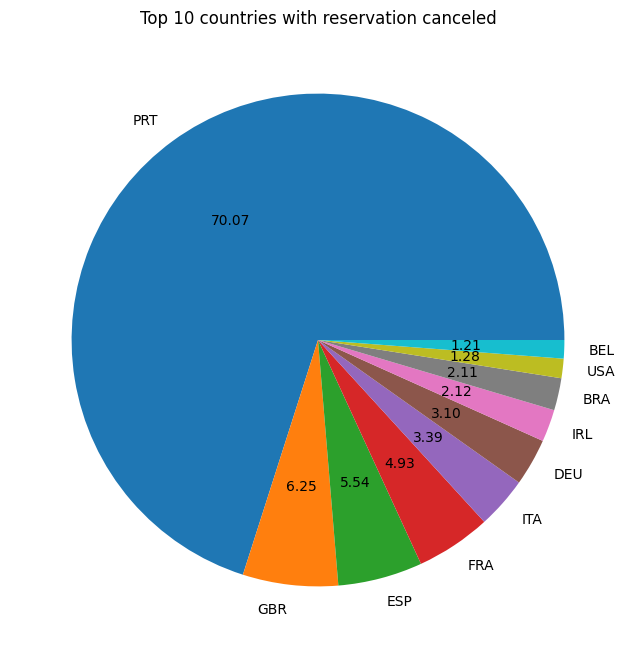

In [76]:
canceled_data = df[df['is_canceled']==1]
top_10_country = canceled_data['country'].value_counts()[:10]
plt.figure(figsize=(10,8))
plt.title('Top 10 countries with reservation canceled')
plt.pie(top_10_country, autopct = '%.2f', labels = top_10_country.index)

# To find the percentage of Cancelation
# canceled_data = df[df['is_canceled']==1]
# top_10 = (canceled_data['country'].value_counts(normalize=True) * 100)[:10]
# print(top_10)
# plt.pie(top_10, autopct='%.2f', labels=top_10.index)

In [118]:
df['market_segment'].value_counts()

market_segment
Online TA        56402
Offline TA/TO    24159
Groups           19806
Direct           12448
Corporate         5111
Complementary      734
Aviation           237
Name: count, dtype: int64

In [119]:
df['market_segment'].value_counts(normalize=True)

market_segment
Online TA        0.474377
Offline TA/TO    0.203193
Groups           0.166581
Direct           0.104696
Corporate        0.042987
Complementary    0.006173
Aviation         0.001993
Name: proportion, dtype: float64

In [120]:
canceled_data['market_segment'].value_counts(normalize=True)

market_segment
Online TA        0.469696
Groups           0.273985
Offline TA/TO    0.187466
Direct           0.043486
Corporate        0.022151
Complementary    0.002038
Aviation         0.001178
Name: proportion, dtype: float64

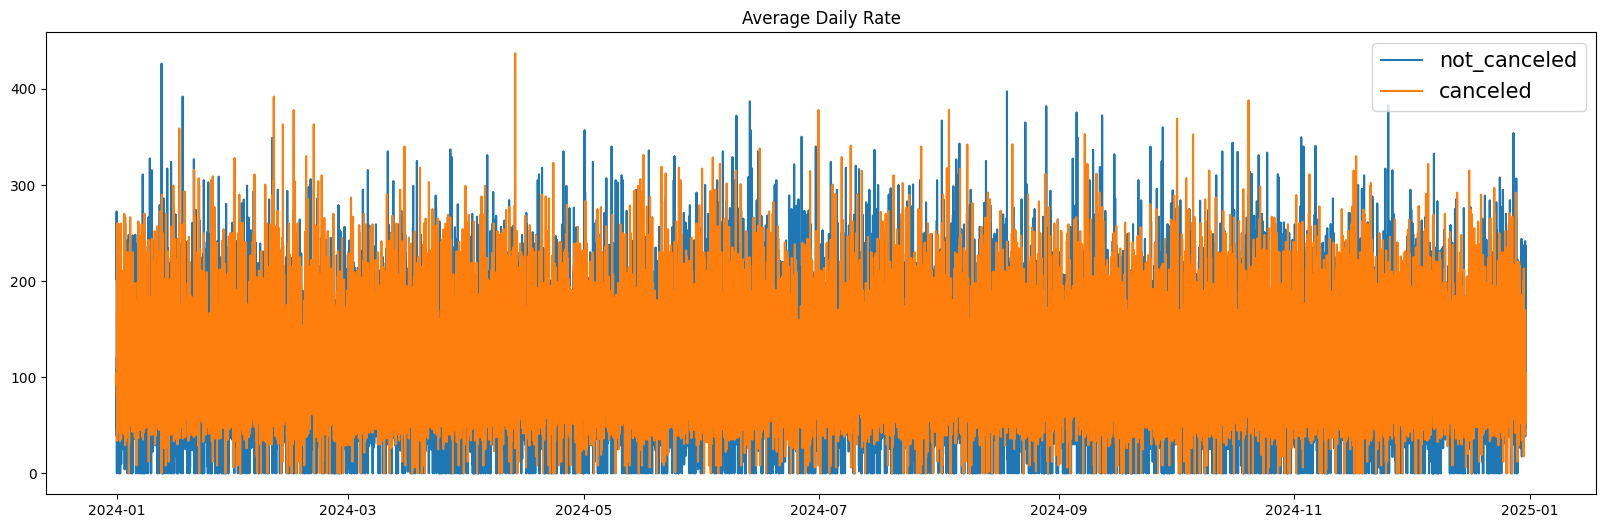

In [128]:
canceled_df_adr = canceled_data.groupby('reservation_status_date')[['adr']].mean()
canceled_df_adr.reset_index(inplace = True)
canceled_df_adr.sort_values('reservation_status_date', inplace = True)

not_canceled_data = df[df['is_canceled'] == 0]
not_canceled_df_adr = not_canceled_data.groupby('reservation_status_date')[['adr']].mean()
not_canceled_df_adr.reset_index(inplace = True)
canceled_df_adr.sort_values('reservation_status_date', inplace = True)

plt.figure(figsize = (20,6))
plt.title('Average Daily Rate')
plt.plot(not_canceled_df_adr['reservation_status_date'], not_canceled_df_adr['adr'], label= 'not_canceled')
plt.plot(canceled_df_adr['reservation_status_date'], canceled_df_adr['adr'], label= 'canceled')
# plt.legend(bbox_to_anchor=(1,1), fontsize=15)
plt.legend(fontsize=15)
plt.show()